<a href="https://colab.research.google.com/github/zvythrox67/Plastic-BuildUp-on-Brain/blob/main/neuron_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

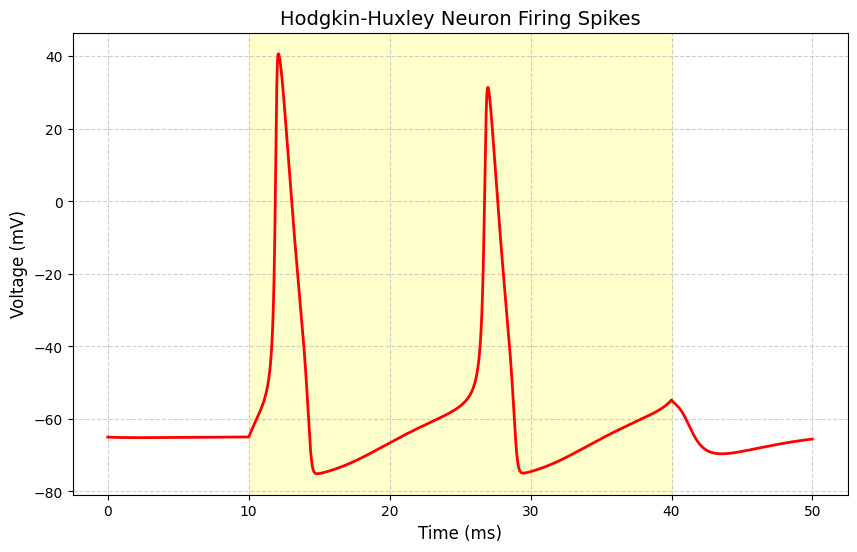

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.01
T = 50.0
t = np.arange(0, T, dt)

C_m = 1.0
g_Na = 120.0
g_K = 36.0
g_L = 0.3
E_Na = 50.0
E_K = -77.0
E_L = -54.387

V = np.zeros(len(t))
V[0] = -65.0

m = np.zeros(len(t))
h = np.zeros(len(t))
n = np.zeros(len(t))
m[0], h[0], n[0] = 0.05, 0.6, 0.32

I_inj = np.zeros(len(t))
I_inj[(t > 10.0) & (t < 40.0)] = 10.0

for i in range(1, len(t)):
    V_now = V[i-1]

    alpha_m = 0.1 * (V_now + 40.0) / (1.0 - np.exp(-(V_now + 40.0) / 10.0)) if V_now != -40.0 else 1.0
    beta_m = 4.0 * np.exp(-(V_now + 65.0) / 18.0)

    alpha_h = 0.07 * np.exp(-(V_now + 65.0) / 20.0)
    beta_h = 1.0 / (1.0 + np.exp(-(V_now + 35.0) / 10.0))

    alpha_n = 0.01 * (V_now + 55.0) / (1.0 - np.exp(-(V_now + 55.0) / 10.0)) if V_now != -55.0 else 0.1
    beta_n = 0.125 * np.exp(-(V_now + 65.0) / 80.0)

    m[i] = m[i-1] + dt * (alpha_m * (1.0 - m[i-1]) - beta_m * m[i-1])
    h[i] = h[i-1] + dt * (alpha_h * (1.0 - h[i-1]) - beta_h * h[i-1])
    n[i] = n[i-1] + dt * (alpha_n * (1.0 - n[i-1]) - beta_n * n[i-1])

    I_Na = g_Na * (m[i]**3) * h[i] * (V_now - E_Na)
    I_K = g_K * (n[i]**4) * (V_now - E_K)
    I_L = g_L * (V_now - E_L)

    V[i] = V[i-1] + dt * ((I_inj[i-1] - I_Na - I_K - I_L) / C_m)

plt.figure(figsize=(10, 6))
plt.plot(t, V, 'r-', linewidth=2)
plt.axvspan(10, 40, color='yellow', alpha=0.2)
plt.title('Hodgkin-Huxley Neuron Firing Spikes', fontsize=14)
plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('Voltage (mV)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


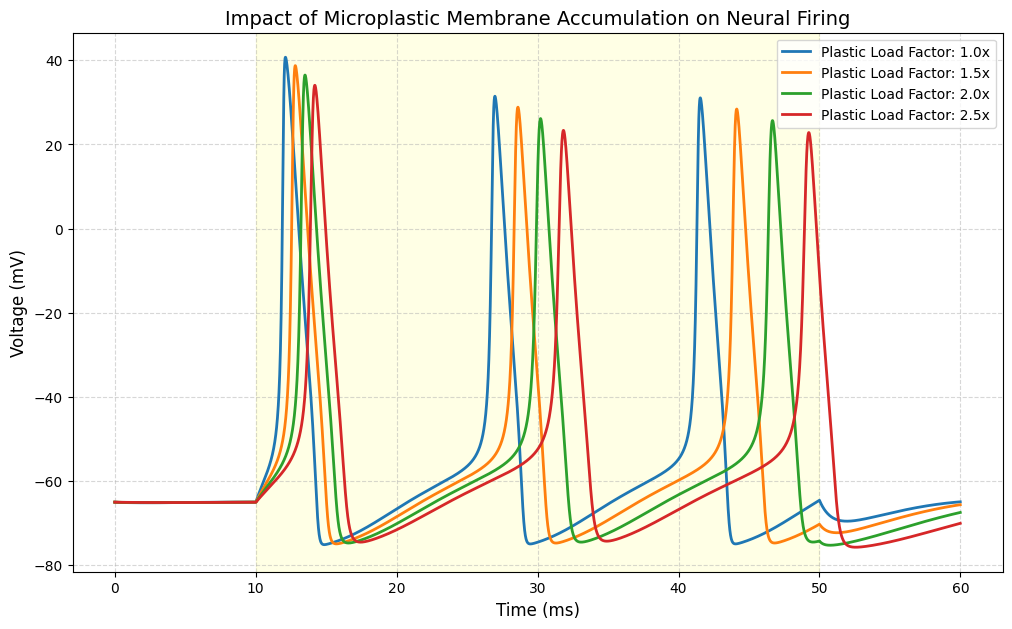

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.01
T = 60.0
t = np.arange(0, T, dt)

plastic_pollution_levels = [1.0, 1.5, 2.0, 2.5]

g_Na = 120.0
g_K = 36.0
g_L = 0.3
E_Na = 50.0
E_K = -77.0
E_L = -54.387

I_inj = np.zeros(len(t))
I_inj[(t > 10.0) & (t < 50.0)] = 10.0

plt.figure(figsize=(12, 7))

for c_scale in plastic_pollution_levels:
    C_m = 1.0 * c_scale

    V = np.zeros(len(t))
    V[:] = -65.0

    m, h, n = 0.05, 0.6, 0.32

    for i in range(1, len(t)):
        V_now = V[i-1]

        alpha_m = 0.1 * (V_now + 40.0) / (1.0 - np.exp(-(V_now + 40.0) / 10.0)) if V_now != -40.0 else 1.0
        beta_m = 4.0 * np.exp(-(V_now + 65.0) / 18.0)
        alpha_h = 0.07 * np.exp(-(V_now + 65.0) / 20.0)
        beta_h = 1.0 / (1.0 + np.exp(-(V_now + 35.0) / 10.0))
        alpha_n = 0.01 * (V_now + 55.0) / (1.0 - np.exp(-(V_now + 55.0) / 10.0)) if V_now != -55.0 else 0.1
        beta_n = 0.125 * np.exp(-(V_now + 65.0) / 80.0)

        m = m + dt * (alpha_m * (1.0 - m) - beta_m * m)
        h = h + dt * (alpha_h * (1.0 - h) - beta_h * h)
        n = n + dt * (alpha_n * (1.0 - n) - beta_n * n)

        I_Na = g_Na * (m**3) * h * (V_now - E_Na)
        I_K = g_K * (n**4) * (V_now - E_K)
        I_L = g_L * (V_now - E_L)

        V[i] = V[i-1] + dt * ((I_inj[i-1] - I_Na - I_K - I_L) / C_m)

    plt.plot(t, V, label=f'Plastic Load Factor: {c_scale}x', linewidth=2)

plt.axvspan(10, 50, color='yellow', alpha=0.1)
plt.title('Impact of Microplastic Membrane Accumulation on Neural Firing', fontsize=14)
plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('Voltage (mV)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [ ]:
import numpy as np

plastic_levels = [1.0, 1.5, 2.0, 2.5]
print(f"{'Plastic Load':<15}{'First Spike (ms)':<20}{'Peak Voltage (mV)':<20}{'Spike Count':<15}")
print("-" * 70)

for c_scale in plastic_levels:
    C_m = 1.0 * c_scale
    V = np.zeros(len(t))
    V[:] = -65.0
    m, h, n = 0.05, 0.6, 0.32

    for i in range(1, len(t)):
        V_now = V[i-1]
        alpha_m = 0.1*(V_now+40.0)/(1.0-np.exp(-(V_now+40.0)/10.0)) if V_now != -40.0 else 1.0
        beta_m = 4.0*np.exp(-(V_now+65.0)/18.0)
        alpha_h = 0.07*np.exp(-(V_now+65.0)/20.0)
        beta_h = 1.0/(1.0+np.exp(-(V_now+35.0)/10.0))
        alpha_n = 0.01*(V_now+55.0)/(1.0-np.exp(-(V_now+55.0)/10.0)) if V_now != -55.0 else 0.1
        beta_n = 0.125*np.exp(-(V_now+65.0)/80.0)

        m += dt * (alpha_m*(1.0-m) - beta_m*m)
        h += dt * (alpha_h*(1.0-h) - beta_h*h)
        n += dt * (alpha_n*(1.0-n) - beta_n*n)

        I_Na = g_Na*(m**3)*h*(V_now-E_Na)
        I_K = g_K*(n**4)*(V_now-E_K)
        I_L = g_L*(V_now-E_L)
        V[i] = V[i-1] + dt*((I_inj[i-1]-I_Na-I_K-I_L)/C_m)

    peaks = []
    for k in range(1, len(V)-1):
        if V[k] > V[k-1] and V[k] > V[k+1] and V[k] > 0:
            peaks.append(k)

    spike_count = len(peaks)
    first_spike_time = round(peaks[0] * dt, 2) if spike_count > 0 else "N/A"
    max_volt = round(np.max(V), 2)

    print(f"{c_scale:<15}{first_spike_time:<20}{max_volt:<20}{spike_count:<15}")


Plastic Load   First Spike (ms)    Peak Voltage (mV)   Spike Count    
----------------------------------------------------------------------
1.0            12.11               40.73               3              
1.5            12.81               38.73               3              
2.0            13.5                36.49               3              
2.5            14.19               34.06               3              
